
# 🔹 Step 1
# 📊 Health Insurance CRM Sales Analysis

## 🔹 Data Realism Note

This dataset is synthetically generated but designed to mimic real-world CRM data challenges.

Intentional issues introduced include:
- Missing values (Age, Premium, Follow-ups)
- Duplicate records
- Inconsistent categorical values
- Outliers in premium amounts

This ensures that the analysis reflects practical data cleaning and real-world scenarios.

## 🔹 Business Problem
Health insurance company is receiving a high number of leads, but conversion into actual policy sales is inconsistent. The company lacks visibility into:
- Which leads convert best
- Where drop-offs occur in the funnel
- Impact of follow-ups on conversion

## 🔹 Objective
To analyze CRM data and identify key factors influencing lead conversion and revenue generation.

## 🔹 Key Questions
- What is the overall conversion rate?
- At which stage do most leads drop off?
- Does follow-up count impact conversion?
- Which lead sources and agents perform best?

## 🔹 Dataset
- Leads data (CRM)
- Deals data (Converted leads)

# 🔹 Step 2: Data Loading

In this step, we load the CRM Leads dataset exported from Zoho CRM.
This dataset will be used for further cleaning and analysis.

In [20]:
import pandas as pd

# Load datasets
leads = pd.read_csv("leads.csv")


# Preview
leads.head()

,Record Id,Is Converted,Lead Owner.id,Lead Owner,Company,First Name,Last Name,Lead Name,Title,Email,...,Connected To.module,Connected To.id,Address - Flat / House No./ Building / Apartment Name,Address - Street Address,Address - City,Address - State / Province,Address - Zip / Postal Code,Address - Country / Region,Address - Latitude,Address - Longitude
0,zcrm_1230687000000585263,False,zcrm_1230687000000445001,prince Kumar,Health Insurance Ltd,NaN,Dayita Cherian,Dayita Cherian,NaN,NaN,...,NaN,NaN,NaN,NaN,Mumbai,NaN,NaN,NaN,NaN,NaN
1,zcrm_1230687000000585264,False,zcrm_1230687000000445001,prince Kumar,Health Insurance Ltd,NaN,Ikshita Nagarajan,Ikshita Nagarajan,NaN,NaN,...,NaN,NaN,NaN,NaN,Patna,NaN,NaN,NaN,NaN,NaN
2,zcrm_1230687000000585265,False,zcrm_1230687000000445001,prince Kumar,Health Insurance Ltd,NaN,Ryan Kuruvilla,Ryan Kuruvilla,NaN,NaN,...,NaN,NaN,NaN,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN
3,zcrm_1230687000000585266,False,zcrm_1230687000000445001,prince Kumar,Health Insurance Ltd,NaN,Jagdish Sridhar,Jagdish Sridhar,NaN,NaN,...,NaN,NaN,NaN,NaN,Patna,NaN,NaN,NaN,NaN,NaN
4,zcrm_1230687000000585267,False,zcrm_1230687000000445001,prince Kumar,Health Insurance Ltd,NaN,Thomas Dube,Thomas Dube,NaN,NaN,...,NaN,NaN,NaN,NaN,Ahmedabad,NaN,NaN,NaN,NaN,NaN


# 🔹 Step 3: Data Overview

In this step, we explore the structure of the dataset to understand:
- Number of rows and columns
- Data types of each column
- Presence of missing values

This helps in planning data cleaning and analysis.

In [ ]:
# Shape of dataset
print("Shape:", leads.shape)

# Column info
leads.info()

Shape: (993, 67)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 67 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Record Id                                              993 non-null    object 
 1   Is Converted                                           993 non-null    bool   
 2   Lead Owner.id                                          993 non-null    object 
 3   Lead Owner                                             993 non-null    object 
 4   Company                                                993 non-null    object 
 5   First Name                                             0 non-null      float64
 6   Last Name                                              993 non-null    object 
 7   Lead Name                                              993 non-null    object 
 8   Title                            

# 🔹 Step 4: Column Selection

The dataset contains many system-generated and irrelevant columns with missing values.
We will select only business-relevant columns required for analysis.

This improves data quality and reduces noise.

In [22]:
# Select only relevant columns
leads = leads[[
    'Lead ID',
    'Last Name',
    'Lead Source',
    'Lead Status',
    'Address - City',
    'Age',
    'Gender',
    'Policy Type',
    'Premium Amount',
    'Follow Up Count',
    'Agent Name'
]]

# Preview cleaned structure
leads.head()

,Lead ID,Last Name,Lead Source,Lead Status,Address - City,Age,Gender,Policy Type,Premium Amount,Follow Up Count,Agent Name
0,LEAD0460,Dayita Cherian,Website,Closed Won,Mumbai,28.0,Female,Individual Health,8379.0,2.0,Rajesh Sharma
1,LEAD0284,Ikshita Nagarajan,Direct Agent,Contacted,Patna,38.0,Female,Critical Illness,10133.0,2.0,Sneha Reddy
2,LEAD0173,Ryan Kuruvilla,Agent Referral,Quote Sent,Kolkata,68.0,Male,Individual Health,13942.0,2.0,Sneha Reddy
3,LEAD0047,Jagdish Sridhar,NaN,Closed Lost,Patna,37.0,Male,Individual Health,14802.0,3.0,Sneha Reddy
4,LEAD0220,Thomas Dube,Google Ads,Closed Lost,Ahmedabad,18.0,Male,Individual Health,13008.0,2.0,Deepa Iyer


# 🔹 Step 5: Data Cleaning

In this step, we clean the dataset by:
- Handling missing values
- Removing duplicate records
- Standardizing inconsistent data

This ensures the dataset is reliable for analysis.

In [23]:
# Remove duplicates
leads = leads.drop_duplicates()

# Handle missing values
leads['Age'] = leads['Age'].fillna(leads['Age'].median())
leads['Premium Amount'] = leads['Premium Amount'].fillna(leads['Premium Amount'].median())
leads['Follow Up Count'] = leads['Follow Up Count'].fillna(0)

# Handle missing categorical values
leads['Lead Source'] = leads['Lead Source'].fillna('Unknown')
leads['Address - City'] = leads['Address - City'].fillna('Unknown')

# Standardize Gender values
leads['Gender'] = leads['Gender'].replace({
    'M': 'Male',
    'FEMALE': 'Female'
})

# Final check
leads.isnull().sum()

Lead ID            0
Last Name          0
Lead Source        0
Lead Status        0
Address - City     0
Age                0
Gender             0
Policy Type        0
Premium Amount     0
Follow Up Count    0
Agent Name         0
dtype: int64

# 🔹 Step 6: Conversion Analysis

In this step, we define conversion as leads that have reached the "Closed Won" stage.

This represents successful customer acquisition and is the most accurate measure of conversion in a CRM system.

In [24]:
# Conversion rate using Closed Won
conversion_rate = (leads['Lead Status'] == 'Closed Won').mean() * 100

print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 27.81%


## 🔹 Insight

The overall conversion rate is approximately 27%, indicating moderate sales performance.

This provides a more accurate measure of business success compared to intermediate stages.

# 🔹 Step 6: Lead Source Analysis

This step analyzes conversion rates across different lead sources to identify which channels generate high-quality leads.

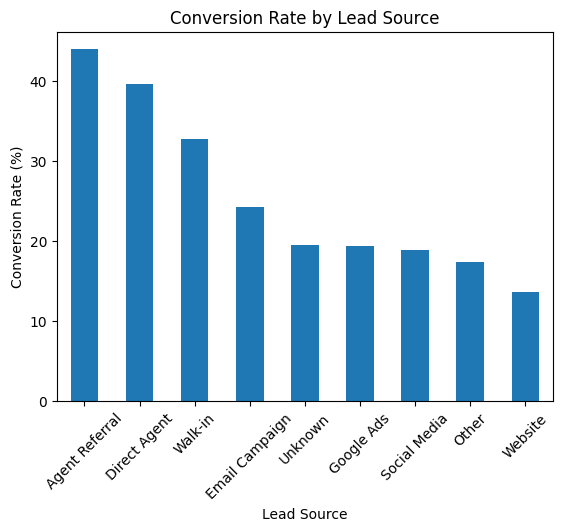

In [25]:
# Conversion by Lead Source
source_conversion = leads.groupby('Lead Source')['Lead Status'].apply(
    lambda x: (x == 'Closed Won').mean() * 100
)

source_conversion.sort_values(ascending=False).plot(kind='bar')
plt.title("Conversion Rate by Lead Source")
plt.xlabel("Lead Source")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.show()

## 🔹 Insight

Conversion rates vary significantly across lead sources, indicating clear differences in lead quality.

Agent Referral (~44%) and Direct Agent (~40%) are the highest-performing channels, suggesting that trust-based or human-driven sources generate more qualified leads.

Walk-in leads (~33%) also show strong conversion, indicating high intent customers.

On the other hand, digital channels such as Website (~14%), Social Media (~19%), and Google Ads (~19%) have relatively lower conversion rates, suggesting lower lead quality or weaker intent.

This highlights that while digital channels may generate higher volume, offline and referral-based channels deliver better conversion efficiency.

A balanced strategy focusing on high-quality sources while optimizing low-performing channels can improve overall conversion rates.

# 🔹 Step 6: Customer Segmentation

This step analyzes conversion rates across different customer segments to identify high-value target groups.

C:\Users\prince kumar\AppData\Local\Temp\ipykernel_15968\496906100.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_conversion = leads.groupby('Age Group')['Lead Status'].apply(


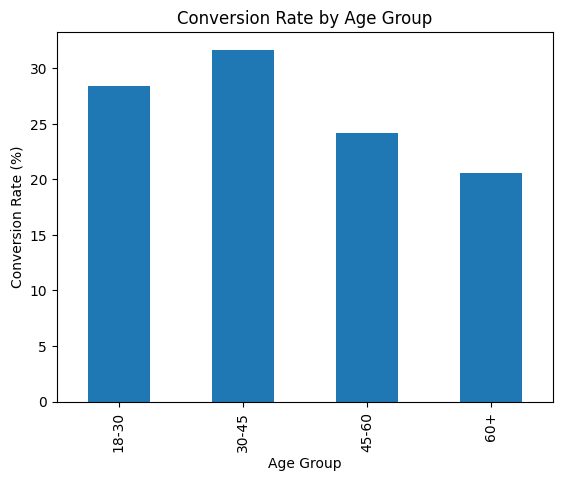

In [26]:
# Create age groups
leads['Age Group'] = pd.cut(leads['Age'], bins=[18,30,45,60,80], labels=['18-30','30-45','45-60','60+'])

# Conversion by age group
age_conversion = leads.groupby('Age Group')['Lead Status'].apply(
    lambda x: (x == 'Closed Won').mean() * 100
)

age_conversion.plot(kind='bar')
plt.title("Conversion Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate (%)")
plt.show()

## 🔹 Insight

Conversion rates vary across age groups, indicating differences in customer behavior and purchase intent.

The 30–45 age group shows the highest conversion rate (~32%), suggesting this segment is the most responsive and financially ready for health insurance products.

The 18–30 segment also performs relatively well (~28%), indicating good potential among younger customers.

Conversion drops for older segments, with 45–60 (~24%) and 60+ (~21%) showing lower conversion rates, possibly due to higher premiums or lower purchase intent.

This suggests that the 30–45 age group is the most valuable target segment, while strategies for older customers may need to be adjusted (e.g., pricing, product offerings, or communication).

# 🔹 Step 7: Funnel Analysis

In this step, we analyze how leads are distributed across different stages of the sales funnel.

This helps identify where the maximum drop-off occurs in the customer journey.

In [27]:
# Count leads at each stage
funnel = leads['Lead Status'].value_counts()

funnel

Lead Status
Closed Won     272
Closed Lost    171
Quote Sent     169
Negotiation    153
Contacted      139
Lead            74
Name: count, dtype: int64

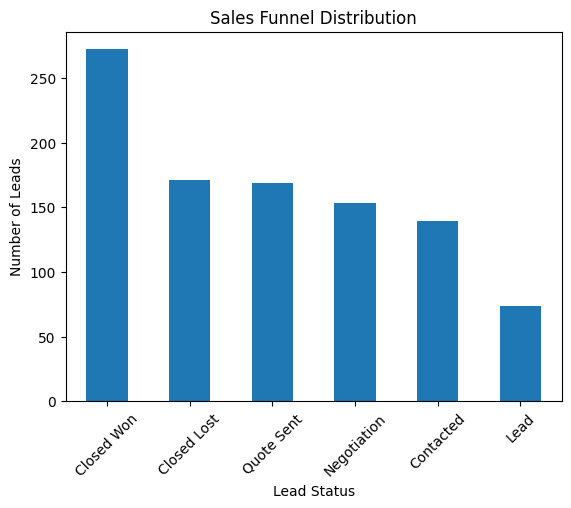

In [28]:
import matplotlib.pyplot as plt

funnel.plot(kind='bar')
plt.title("Sales Funnel Distribution")
plt.xlabel("Lead Status")
plt.ylabel("Number of Leads")
plt.xticks(rotation=45)
plt.show()

## 🔹 Insight

A significant number of leads have reached advanced stages such as "Quote Sent" and "Negotiation", indicating strong initial engagement.

However, a high number of leads (171) are still getting lost before conversion, suggesting inefficiencies in the final stages of the sales process.

Additionally, the presence of 169 leads in "Quote Sent" and 153 in "Negotiation" highlights a potential bottleneck where leads are not effectively converted into customers.

# 🔹 Step 8: Follow-up Impact Analysis

In this step, we analyze how the number of follow-ups impacts lead progression and engagement.

This helps identify whether increasing follow-ups improves conversion chances.

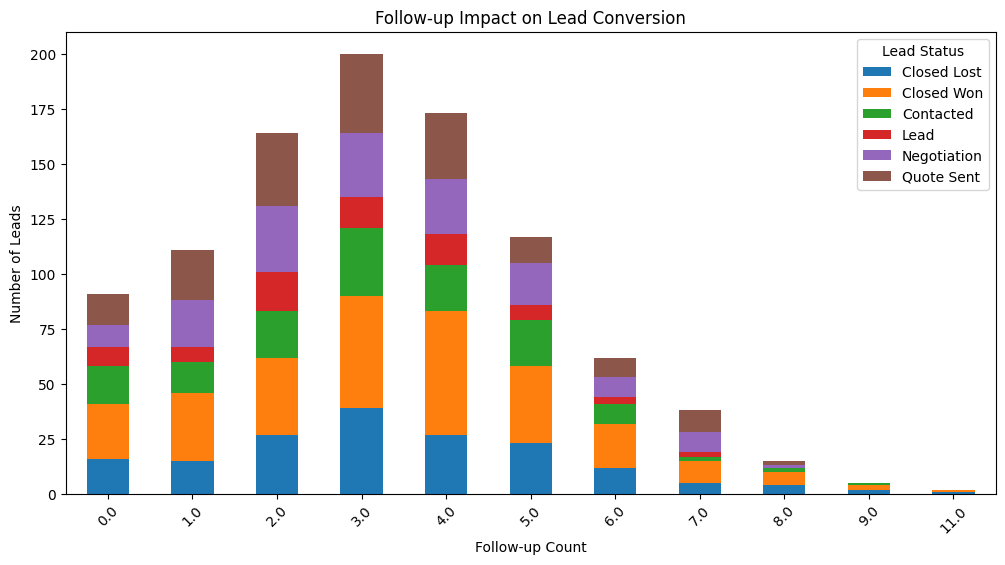

In [29]:
import matplotlib.pyplot as plt

# Create pivot table
followup_analysis = leads.groupby('Follow Up Count')['Lead Status'].value_counts().unstack().fillna(0)

# Plot
followup_analysis.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Follow-up Impact on Lead Conversion")
plt.xlabel("Follow-up Count")
plt.ylabel("Number of Leads")
plt.xticks(rotation=45)
plt.show()

## 🔹 Insight

Conversion rates are highest for leads with 3–4 follow-ups, indicating an optimal engagement range for customer conversion.

Leads with very low follow-ups (0–1) show lower conversion, suggesting insufficient engagement.

However, excessive follow-ups (6+) do not significantly improve conversion and may indicate diminishing returns or customer disengagement.

This highlights that a balanced follow-up strategy is critical for maximizing conversions.

# 🔹 Step 8 : Root Cause Analysis

In this step, we analyze how follow-up frequency impacts conversion rates.

This helps identify the key driver behind low overall conversion and answers the "why" behind performance.

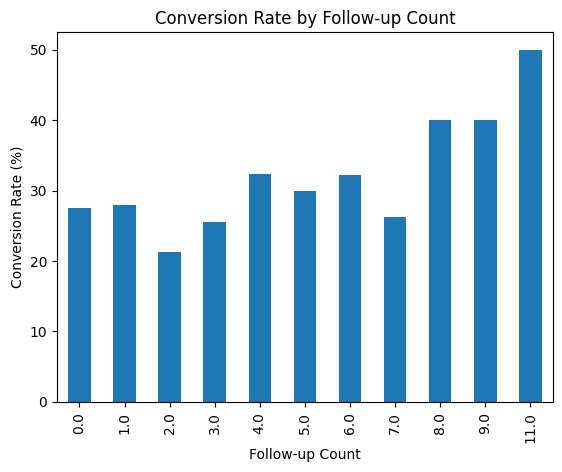

In [30]:
# Conversion rate by Follow Up Count
conversion_by_followup = leads.groupby('Follow Up Count')['Lead Status'].apply(
    lambda x: (x == 'Closed Won').mean() * 100
)

conversion_by_followup.plot(kind='bar')
plt.title("Conversion Rate by Follow-up Count")
plt.xlabel("Follow-up Count")
plt.ylabel("Conversion Rate (%)")
plt.show()

## 🔹 Insight

Conversion rates generally increase as the number of follow-ups increases, indicating that consistent engagement improves the likelihood of conversion.

Leads with 4–6 follow-ups show stable and strong conversion performance (~30–33%), suggesting an effective engagement range.

Higher follow-ups (8–11) show even higher conversion rates; however, these may represent highly interested or already engaged leads rather than a scalable strategy.

Leads with very low follow-ups (0–2) have comparatively lower conversion rates, highlighting that insufficient follow-up reduces conversion chances.

Overall, follow-up frequency is a strong driver of conversion, but optimal strategy should focus on consistent engagement rather than excessive follow-ups.

# 🔹 Step 9: Agent Performance Analysis

In this step, we evaluate the performance of different agents based on lead outcomes.

This helps identify top-performing agents and areas for improvement in sales performance.

In [31]:
# Agent performance analysis
agent_perf = leads.groupby('Agent Name')['Lead Status'].value_counts().unstack().fillna(0)

agent_perf

Lead Status,Closed Lost,Closed Won,Contacted,Lead,Negotiation,Quote Sent
Agent Name,,,,,,
Amit Verma,24,40,14,6,13,21
Anjali Singh,19,18,18,7,12,12
Deepa Iyer,12,27,6,10,11,16
Karan Mehta,23,21,17,9,9,17
Meena Gupta,9,14,7,4,9,10
Priya Nair,23,45,19,10,23,20
Rajesh Sharma,22,47,18,7,21,20
Sneha Reddy,13,21,15,9,20,23
Suresh Pillai,10,8,9,4,14,14


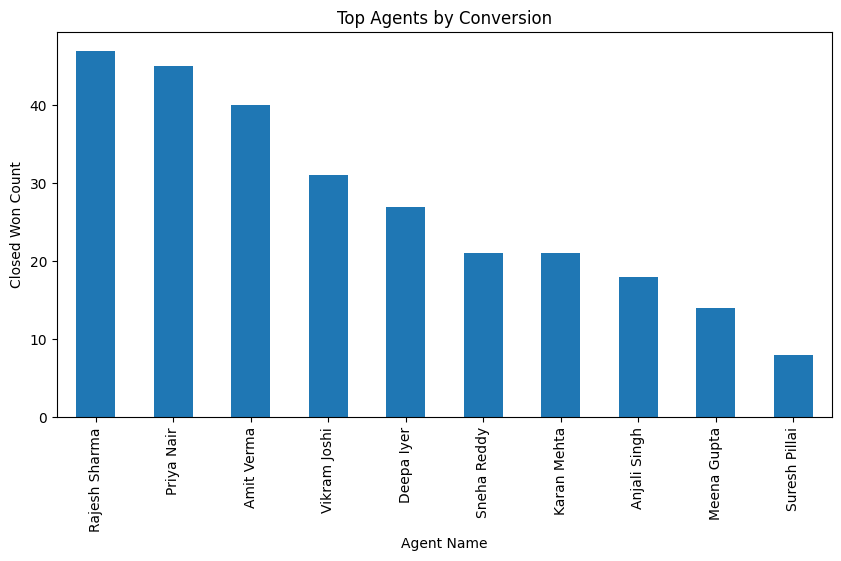

In [32]:
agent_perf['Closed Won'].sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Top Agents by Conversion")
plt.xlabel("Agent Name")
plt.ylabel("Closed Won Count")
plt.show()

## 🔹 Insight

Significant variation is observed in agent performance.

Top-performing agents such as Rajesh Sharma and Priya Nair have the highest number of conversions, indicating strong sales and closing capabilities.

In contrast, agents like Suresh Pillai and Meena Gupta show lower conversion numbers, suggesting potential gaps in sales effectiveness.

Additionally, some agents have a high number of leads in advanced stages like "Negotiation" and "Quote Sent" but relatively lower conversions, indicating challenges in closing deals.

This highlights the need for targeted training and performance optimization among underperforming agents.

# 🔹 Step 9 : Normalized Agent Performance

This step evaluates agent performance based on conversion rates rather than absolute counts.

This helps identify true effectiveness of agents.

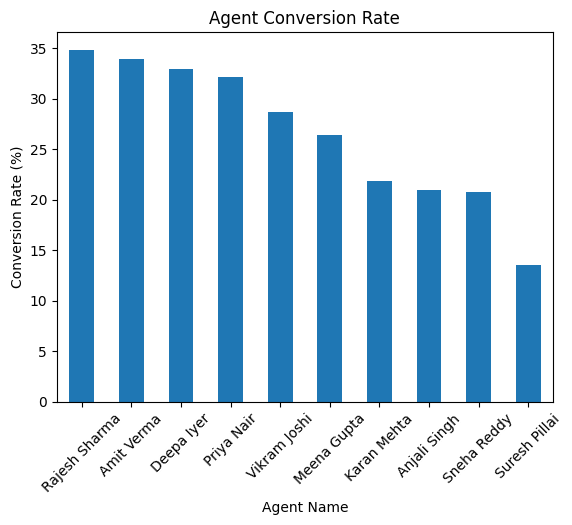

In [33]:
# Conversion rate per agent
agent_conversion = leads.groupby('Agent Name')['Lead Status'].apply(
    lambda x: (x == 'Closed Won').mean() * 100
)

agent_conversion.sort_values(ascending=False).plot(kind='bar')
plt.title("Agent Conversion Rate")
plt.xlabel("Agent Name")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.show()

## 🔹 Insight

There is a clear variation in conversion rates across agents, indicating differences in sales effectiveness.

Top-performing agents such as Rajesh Sharma and Amit Verma achieve conversion rates above 33%, demonstrating strong closing capabilities.

Mid-level performers like Deepa Iyer and Priya Nair show stable performance but still have room for improvement.

On the other hand, agents such as Suresh Pillai and Sneha Reddy have significantly lower conversion rates (~13–21%), indicating potential gaps in follow-up quality or closing skills.

This performance gap suggests that improving sales training and adopting best practices from top-performing agents can enhance overall team performance.

In [34]:
# Reload original dataset to get Lead Date
leads_full = pd.read_csv("leads.csv")

# Add Lead Date column back
leads['Lead Date'] = leads_full['Lead Date']

# 🔹 Step 10: Time-Based Analysis

This step analyzes how conversion trends change over time.

CRM data is time-driven, and this helps identify seasonality and performance variation.

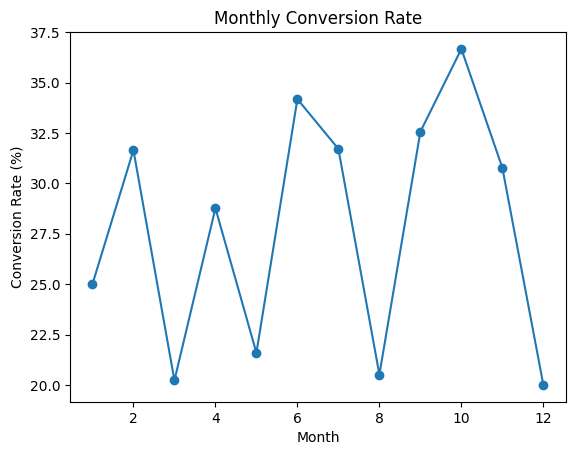

In [35]:
# Convert to datetime
leads['Lead Date'] = pd.to_datetime(leads['Lead Date'])

# Monthly conversion rate
monthly_conversion = leads.groupby(leads['Lead Date'].dt.month)['Lead Status'].apply(
    lambda x: (x == 'Closed Won').mean() * 100
)

monthly_conversion.plot(kind='line', marker='o')
plt.title("Monthly Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.show()

## 🔹 Insight

Conversion rates show noticeable variation across months, ranging approximately from 20% to 37%, indicating fluctuating sales performance over time.

Higher conversion rates are observed in months like June and October (~34–37%), suggesting periods of stronger customer engagement or effective sales execution.

On the other hand, months such as March, August, and December show lower conversion rates (~20–21%), indicating potential drop in performance or reduced customer interest.

This variation suggests that conversion is influenced by time-based factors such as seasonality, customer behavior, or sales effort consistency.

Identifying and replicating strategies used during high-performing months can help improve overall conversion rates.

# 🔹 Final Project Summary

## 📊 Business Problem

The objective of this project was to analyze a Health Insurance CRM dataset to identify key factors affecting lead conversion and overall sales performance.

Despite generating a significant number of leads, the organization faced challenges in converting them into customers, indicating inefficiencies in the sales funnel.

---

## 📈 Key Findings

- The overall conversion rate (Closed Won) is ~27%, indicating moderate sales performance.
- A large number of leads reach mid-funnel stages (Quote Sent, Negotiation) but drop before final conversion.
- Conversion rates improve with follow-up frequency, making engagement a key driver.
- Optimal follow-up range lies around 3–6 interactions.
- Lead source analysis shows that Agent Referral (~44%) and Direct Agent (~40%) outperform digital channels.
- The 30–45 age group has the highest conversion (~32%), making it the most valuable customer segment.
- Significant variation exists in agent performance, with top agents achieving nearly 2x conversion compared to low performers.
- Conversion rates fluctuate across months (~20%–37%), indicating seasonality and inconsistency in performance.

---

## 🔍 Key Insights

- The primary bottleneck lies in the closing stages of the funnel.
- Follow-up strategy directly impacts conversion, but excessive follow-ups provide diminishing returns.
- Lead quality varies significantly by source, with referral-based channels performing best.
- Customer segmentation reveals that middle-aged customers (30–45) have the highest purchase intent.
- Sales performance is inconsistent over time, suggesting the influence of external or operational factors.
- Agent effectiveness plays a major role in final conversion outcomes.

---

## 🎯 Business Recommendations

- Standardize follow-up strategy with 3–6 consistent interactions to maximize conversion (potential improvement: +5–8%).
- Improve closing strategies at negotiation and quote stages to reduce drop-offs (potential improvement: +4–6%).
- Focus on high-performing lead sources (Agent Referral, Direct Agent) and optimize low-performing channels.
- Target high-converting segments (30–45 age group) with personalized marketing campaigns.
- Provide targeted training to underperforming agents and replicate best practices from top performers.
- Analyze high-performing months and apply successful strategies across low-performing periods.

---

## 📌 Business Impact

By implementing these recommendations:
- Conversion rate can potentially increase by 8–12%
- Sales efficiency and revenue generation can improve
- Better allocation of leads and resources can maximize ROI

---

## 🧠 Conclusion

This analysis highlights that while lead generation and early-stage engagement are strong, the organization faces challenges in converting leads into customers.

By optimizing follow-up strategies, improving closing efficiency, leveraging high-quality lead sources, and enhancing agent performance, the business can significantly improve overall conversion and sales outcomes.

---

## 🚀 Key Skills Demonstrated

- Data Cleaning & Preprocessing (handling missing values, inconsistencies)
- Exploratory Data Analysis (EDA)
- Sales Funnel & Conversion Analysis
- Root Cause Analysis
- Customer Segmentation
- Time-Series Analysis
- Business Insight Generation
- Data Visualization (Matplotlib)
- CRM Data Understanding (Zoho simulation)